<a href="https://colab.research.google.com/github/neel-p8/Approximate-Integrals-and-Derive-Pi/blob/main/Neel_Patel_HW1_Fall23.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 1, Lin. Alg. for Data Science.
# Due date: Tue 26 September, 2023 (by end of day AOE).

# Collaboration rules:
> For this task, I'd prefer you **work on your own**. But feel free to ask for clarification on discord. Make sure you don't spoil the tasks for others though.

# Instructions:
0. Solve the tasks (by writing python code and answering extra questions, if any).

1. **Rename the notebook** like this: FirstName_LastName_HW1.ipynb (e.g. I'd rename it as: Hubert_Wagner_HW1.ipynb)

2. Run all the cells in the notebook, so that all results are visible.

3. **Important**: on colab create a shared link using the option **"for anyone with the link"** and switch permission from **Viewer** to **Editor**, so that it says "Anyone on the internet with the link can edit". Otherwise, I won't be able to read your work!

4. Submit the above link on canvas.

5. Later, *when the time comes* answer some brief questions about your solution via a google form I will send you. **This is part of the homework assignment**, so don't miss it!



# Task 1: Approximating hard integrals [1 point]

> okay, some of them are not so hard.

Implement a python function which can approximate the value of a definite integral a mathematical function. It is not necessary to use any sophisticated approach.

Use it to evaluate the following definite integrals:
- $$\int_0^{\frac{\pi}{2}} \arccos{\frac{\cos{x}}{1 + 2\cos{x}}}\,dx\, .$$
- $$\int_0^{e} \cosh x dx\, .$$
- $$\int_1^{e} \frac{1}{x} dx\, .$$
- $$\int_0^{1} 1 dx\, .$$

> Use numpy -- **except for functions like np.trapz** which do the entire job for you. You should implement your own simple integration method.

Report and **test** your answers, making sure each result is correct up to 5 decimal digits. More precisely test if $|res - correct| < 10^{-5}$.

> (Hint: the exact values are $\frac{5}{24}\pi^2$, $ \frac{e^e - e^{-e}}{2}$, $1$ and $1$.)

> Write automated tests using assert statements (ideally we'd use the pytest framework, but it doesn't mesh well with timing code which we'll also do).

> Additionally, the last integral has to be evaluated correctly using a small number of steps, say, 1,2, or 3 (using the same function as the others without handling this extra case in a special way). It's essentially meant as a unit test for your algorithm and its implementation. You can use the python function provided below.



In [ ]:
import numpy as np
# this is useful for the last example.
def constant_function_of_one(x):
    '''Evaluates a constant function returning 1.
    It handles both a single number and np.array as input.

    Args:
      x: either a float or np.array of length n
    Returns:
      either a single 1. (as a float) or a length-n np.array of 1.
    '''

    # if input value is float, return 1 else if array return array of 1s
    if type(x) == float:
      return 0 * x + 1.
    elif type(x) == np.ndarray:
        return np.ones_like(x)

In [ ]:
def integrate(function_to_integrate, from_x, to_x, n):

  if type(function_to_integrate) == np.ufunc or type(function_to_integrate) != np.ndarray and type(function_to_integrate) != float:
    # create width of each sample
    delta_x = (to_x - from_x) / n

    # create n samples
    range = np.linspace(from_x, to_x, n + 1)

    # evaluate function at each sample
    y = function_to_integrate(range)

    # calculate using formula
    integral = delta_x * (0.5 * y[0] + np.sum(y[1:-1]) + 0.5*y[-1])

  return integral
  '''
  Following trapezoidal rule, delta x returns the width of each sample. range
  returns n amount of samples. y is the function value at each sample. the
  integral variable returns the trapezoidal rule formula
  '''

# Timing


Run your 'integrate' function on the second example (with $\cosh$) using $n = 10^7$ samples. A good implementation using numpy should take around $0.25s = 250ms$.

In [ ]:
%%timeit
# the line above will time your code

# your function call goes here
integrate(np.cosh, 0, np.exp(1), 10**7)

199 ms ± 35.9 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


# Your tests

Below add tests (asserts) that if your results are close to the correct values. You can use the provided function.


In [ ]:
def close_enough(a, b, num_digits):
  return np.abs(a-b) < 10**-num_digits

# example test checking if res=1.000005 is a good enough approximation
# for the correct result (1). In our case we check if the initial 5
# digits of the decimal expansion match.
res = 1.000003
assert close_enough(1, res, num_digits = 5) # this 'test' passes

# first function
def my_function(x):
  var = np.arccos(np.cos(x) / (1 + 2 * np.cos(x)))
  return var

# tests if first function is correct up to 5 decimal places. Needs 144 samples to fall within boundaries
assert close_enough(integrate(my_function, 0, np.pi / 2, 144), ((5 / 24) * np.pi **2), 5)

# tests if second function is correct up to 5 decimal places. Needs 682 samples to fall within boundaries
assert close_enough(integrate(np.cosh, 0, np.exp(1), 682), ((np.exp(1)**np.exp(1) - np.exp(1)** -np.exp(1)) / 2), 5)

# tests if third function is correct up to 5 decimal places. Needs 146 samples to fall within boundaries
assert close_enough(integrate(lambda x: 1/x, 1, np.exp(1), 146), 1, 5)

# tests if last function is correct up to 5 decimal places.
assert close_enough(integrate(constant_function_of_one, 0, 1, 3), 1, 5)


# Task 2: The value of $\pi$

## Part 0: Preparation [weight = 0.2]

Draw $n=1000$ from the unit square $[0,1]\times[0,1]$. Plot the points which are inside the Euclidean unit ball in green, and the points outside in red.

## The actual problem

They say the value of $\pi$ is $3.141...$ -- but now that we can compute things quickly with numpy, we can call their bluff and verify it ourselves!

To verify the value of $\pi$, we will perform an experiment in which we draw points as in Part 0 (but for a larger $n$). At any moment, we denote $t$ as the total number of points tested so far, and $b$ as the number of these points that were inside the unit ball.

Note that $4\frac{b}{t}$ approximates $\pi$, which allows us to approximate its value as close as we want!

> If you think about it, that's not terribly surprising. If you compute the area of the unit square and the area of the quarter ball (i.e. ball restricted to the unit square), you get $\pi/4$. And the probability that a point sampled (uniformally at random) from some 2-dimensional region of space will be inside some 2-dimensional sub-region depends on the ratio of areas of the two regions.

> Also, we may need a lot of time to get a really good approximation...


## Part 1: Implementation [weight = 0.7]
Implement the above idea.

In a **single experiment** you will draw a total of $n$ points, as described above. You will **repeat the experiment 10 times** using the same value of $n$.

Find the value $n$ for which you get the approximation $3.141$...  (at least 50% of the time). (So if 5 out of your 10 experiments look good, you're good.)

> Important: you don't just want the final approximation for $n$ points -- for full credit you **must keep track** of the approximation you got using the $i$ initial points in the experiment -- **for each** $i$ between $1$ and $n$. So you'll have to be reasonably smart about your computations. Hint: we did something similar in class!

## Part 2: Visualization [weight = 0.1]

For each of the 10 experiments, plot how your approximation of $\pi$ changed at each $k$ between $1$ to $n$. So for each experiment you will get a single curve. Plot all curves on a single figure. You should see 10 curves converging to a similar value. Make sure the plot is easy to analyze (for example, you may need to cut some percentage of the initial results, and maybe plot only some fraction of the values).

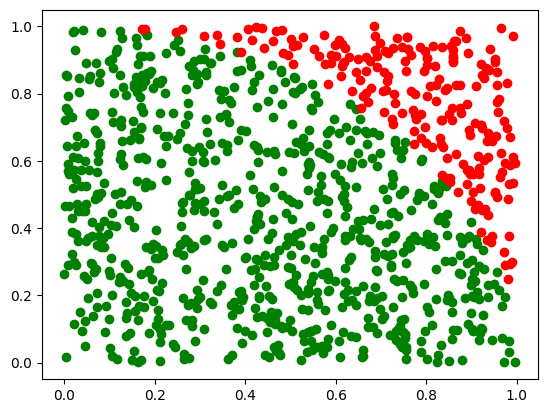

The value of n for which I get the approximation 3.141 is 301207.


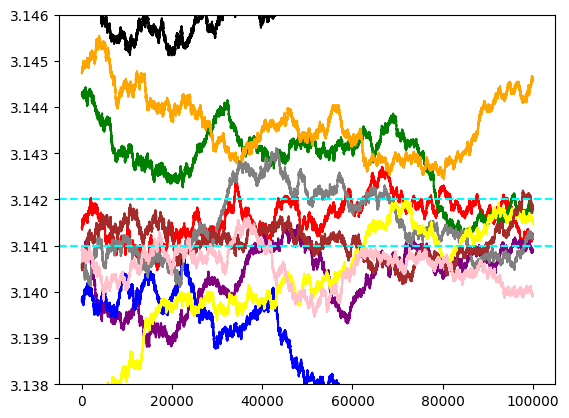

In [ ]:
# part 0
import matplotlib.pyplot as plt

# plot 1000 random points. Check if inside or outside circle, plot green/red
P = np.random.rand(1000,2)
norms = np.linalg.norm(P, axis = 1)
inside = P[norms <= 1]
outside = P[norms > 1]

plt.scatter(inside[:, 0], inside[:, 1], color = "green")
plt.scatter(outside[:, 0], outside[:, 1], color = "red")

plt.show()

# part 1

# control while loop
loop = True
n = 300000
final_n = 0

# record successes of close approximation
count = 0

while loop:

    # calculate distance from inside circle
    P2 = np.random.rand(n,2)
    norms2 = np.linalg.norm(P2, axis = 1)

    # record number of points inside circle
    inside2 = np.sum(norms2 <= 1)

    # approximate pi using formula and if within 0.001, count as success
    approximation = 4 * inside2 / n
    if approximation <= 3.142 and approximation >= 3.141:
      loop = False
      final_n = n
      trials_test = np.empty((10, final_n))

      # test n value with 10 experiments
      for i in range(10):
        P_test = np.random.rand(final_n, 2)
        norms_test = np.linalg.norm(P_test, axis = 1)

        # record number of points inside circle
        inside_test2 = np.cumsum(norms_test <= 1)

        # Approximate pi for all 'n' values at once
        trials_test[i] = 4 * inside_test2 / np.arange(1, final_n + 1)

        # approximate pi using formula and if between 3.141 and 3.142, count as success
        if trials_test[i][final_n - 1] <= 3.142 and trials_test[i][final_n - 1] >= 3.141:
            count += 1

        # if 50% of trials successful, and 10 trials run, break out of while loop
        if count >= 5 and i == 9:
            loop = False
        elif i == 9 and count < 5:
            trials_test = np.empty((10, final_n))
            loop = True
            count = 0
    n += 1

print(f"The value of n for which I get the approximation 3.141 is {final_n}.")

# Part 2
plt.plot(trials_test[0][-100000:], color = 'red')
plt.plot(trials_test[1][-100000:], color = 'purple')
plt.plot(trials_test[2][-100000:], color = 'blue')
plt.plot(trials_test[3][-100000:], color = 'green')
plt.plot(trials_test[4][-100000:], color = 'orange')
plt.plot(trials_test[5][-100000:], color = 'grey')
plt.plot(trials_test[6][-100000:], color = 'yellow')
plt.plot(trials_test[7][-100000:], color = 'brown')
plt.plot(trials_test[8][-100000:], color = 'pink')
plt.plot(trials_test[9][-100000:], color = 'black')
plt.axhline(y=3.141, color='cyan', linestyle='--')
plt.axhline(y=3.142, color='cyan', linestyle='--')

plt.ylim(3.138, 3.146)
plt.show()


## Clarification: Example experiment for n=10


Here is a output from a single experiment for n = 10:

[0., , 2. , 1.33333333, 1. , 1.6, 2., 1.71428571, 1.5, 1.77777778, 2.]


Each number shows the approximation after considering 1,2,3,...10 points. In particular the first point was outside of the ball, so the approximation is $4\times0/1 = 0$. The second one is $4\times1/2=2$ etc.

Note that the final approximation, namely 2, is terrible and we clearly need a much larger $n$. The last last approximation should look like:

$3.141$[some more digits].

An array like this is what you should compute for a single experiment. And then just repeat 10 times and visualize.


## Clarification: plot in part 2

The plot you produce should look like this. (I cropped the bottom part so that it does not to reveal how large $n$ should be.)

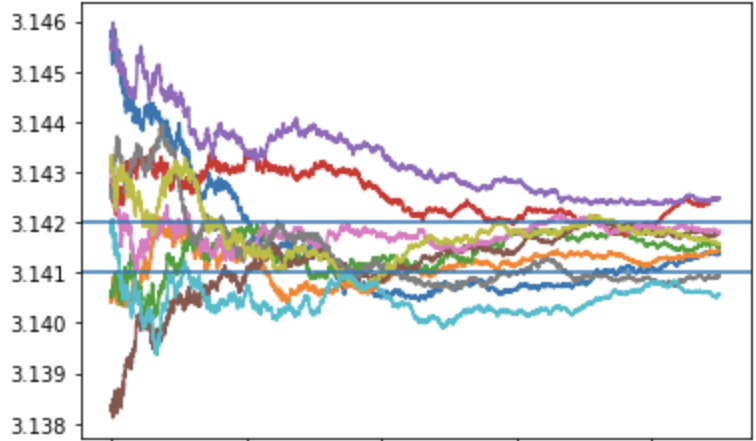

# Evaluation criteria

Later I will send you a form asking a bunch of question about your solutions.

Some things to look out for:
- correctness
- tests for task 1
- clear visualization for task 2
- code readability (good variable and function names)
- good comments (especially for any functions you implement)
- flexibility (in particular in task 1 there should be only 1 implementation)
- efficiency (use numpy wisely, avoid python for loops)